In [1]:
from sklearn.datasets import make_regression

data = make_regression(n_samples = 1000, n_features = 1, bias = 200, noise = 30) 

X = data[0]
y = data[1]

In [17]:
x_train,y_train=X,y
n_data=len(x_train)

In [4]:
import numpy as np
from matplotlib import pyplot as plt

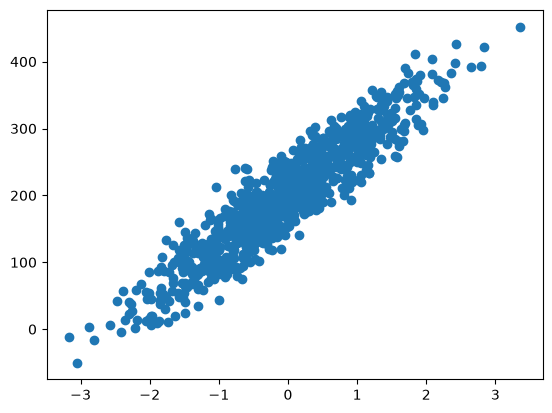

In [8]:
plt.scatter(X,y)
plt.show()

---
### 1. Hypothesis, Cost 정의

In [ ]:
w1=np.random.rand(1)
w0=np.random.rand(1)
print(w1,w0)

[0.70743034] [0.81465951]


In [15]:
hypo=x_train*w1+w0
hypo.shape

(1000, 1)

In [16]:
y_train.shape

(1000,)

In [ ]:
cost=np.sum((y_train-hypo)**2) / n_data

---
### 2. 브로드캐스팅 주의 ⚠️

위 cost는 잘못 계산된다.

- `hypo` : (1000, 1) / `y_train` : (1000,)
- 뺄셈 시 브로드캐스팅되어 (1000, 1000) → 오차가 1000배로 뻥튀기
- `.ravel()` 로 1차원으로 맞춘 뒤 계산해야 한다.

In [ ]:
print((y_train - hypo).shape)           # (1000, 1000) - 브로드캐스팅으로 뻥튀기
print((y_train - hypo.ravel()).shape)   # (1000,) - 올바른 형태

cost = np.sum((y_train - hypo.ravel()) ** 2) / n_data
cost

---
### 3. Gradient (편미분) 유도

$$cost(w_0, w_1) = \frac{1}{N}\sum_{i=1}^{N}\left(y_i - (w_1 x_i + w_0)\right)^2$$

- $\dfrac{\partial cost}{\partial w_1} = \dfrac{2}{N}\sum (\hat{y}_i - y_i)\,x_i$
- $\dfrac{\partial cost}{\partial w_0} = \dfrac{2}{N}\sum (\hat{y}_i - y_i)$

In [ ]:
error = hypo.ravel() - y_train        # (1000,)

# error @ x_train -> sum(error * x) 를 내적으로 한 번에. (1000,) @ (1000,1) = (1,)
dw1 = 2 * (error @ x_train) / n_data
dw0 = 2 * np.mean(error)

print(dw1, dw0)

In [ ]:
# for문으로 계산한 값과 벡터화 결과가 같은지 확인
dw1_loop = 0
for i in range(n_data):
    dw1_loop += (hypo.ravel()[i] - y_train[i]) * x_train[i] * 2
dw1_loop = dw1_loop / n_data

print(dw1_loop, dw1)

---
### 4. 학습 (Gradient Descent)

`w = w - learning_rate * gradient` 를 epochs 만큼 반복

In [ ]:
w1 = np.random.rand(1)
w0 = np.random.rand(1)

epochs = 1000
learning_rate = 0.01
history = {'cost': [], 'w1': [], 'w0': []}

for epoch in range(epochs):
    # 1. 예측
    y_pred = x_train * w1 + w0

    # 2. cost
    error = y_pred.ravel() - y_train
    cost = np.sum(error ** 2) / n_data

    # 3. gradient
    dw1 = 2 * (error @ x_train) / n_data
    dw0 = 2 * np.mean(error)

    # 4. 업데이트
    w1 = w1 - learning_rate * dw1
    w0 = w0 - learning_rate * dw0

    history['cost'].append(cost)
    history['w1'].append(w1[0])
    history['w0'].append(w0[0])

    if epoch % 100 == 0:
        print(f'epoch {epoch:4d} | cost {cost:12.4f} | w1 {w1[0]:8.4f} | w0 {w0[0]:8.4f}')

print(f'\n최종 : y = {w1[0]:.4f}x + {w0[0]:.4f}  (cost {history["cost"][-1]:.4f})')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# cost 감소 곡선
axes[0].plot(history['cost'])
axes[0].set_title('Cost')
axes[0].set_xlabel('epoch')

# 학습된 직선
axes[1].scatter(x_train, y_train, s=8, alpha=0.3, label='data')
xs = np.linspace(x_train.min(), x_train.max(), 100)
axes[1].plot(xs, xs * w1[0] + w0[0], color='red', label='prediction')
axes[1].set_title(f'y = {w1[0]:.2f}x + {w0[0]:.2f}')
axes[1].legend()

plt.show()

---
### 5. 정규방정식(closed form)으로 검증

경사하강법 결과가 맞는지 해석적 해와 비교한다.

In [ ]:
# 정규방정식: theta = (X^T X)^-1 X^T y
Xb = np.c_[np.ones((n_data, 1)), x_train]           # 앞에 1로 된 bias 열 추가 -> (1000, 2)
theta = np.linalg.inv(Xb.T @ Xb) @ Xb.T @ y_train

print(f'정규방정식  : w0={theta[0]:.4f}, w1={theta[1]:.4f}')
print(f'경사하강법  : w0={w0[0]:.4f}, w1={w1[0]:.4f}')

---
### 6. 다중 선형회귀로 일반화

특성이 f개면 `y_pred = X @ weights + bias` 이고, 기울기 규칙은 동일하다.

- $\dfrac{\partial cost}{\partial \mathbf{w}} = \dfrac{2}{N} X^{T}(\hat{y} - y)$
- $\dfrac{\partial cost}{\partial b} = \dfrac{2}{N}\sum(\hat{y} - y)$

In [ ]:
class LinearRegression:
    """numpy만 사용한 선형회귀 (경사하강법)"""

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        n_samples, n_features = X.shape          # X: (n, f), y: (n,)
        self.weights = np.zeros(n_features)      # w1 ... wf
        self.bias = 0.0                          # w0
        self.history = []

        for _ in range(self.epochs):
            y_pred = X @ self.weights + self.bias   # (n,)
            error = y_pred - y                      # (n,)
            self.history.append(np.mean(error ** 2))

            # X.T @ error -> 각 특성별 sum(error * x_j) 를 한 번에 계산
            self.weights = self.weights - self.learning_rate * 2 * (X.T @ error) / n_samples
            self.bias = self.bias - self.learning_rate * 2 * np.mean(error)

        return self

    def predict(self, X):
        return X @ self.weights + self.bias

    def score(self, X, y):
        """결정계수 R^2"""
        y_pred = self.predict(X)
        return 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)

In [ ]:
model = LinearRegression(learning_rate=0.01, epochs=1000)
model.fit(x_train, y_train)

print('weights :', model.weights)
print('bias    :', model.bias)
print('R2      :', model.score(x_train, y_train))

In [ ]:
# 특성이 여러 개여도 코드 수정 없이 동작
X_multi, y_multi = make_regression(n_samples=1000, n_features=10, bias=50, noise=10)

multi_model = LinearRegression(learning_rate=0.05, epochs=2000)
multi_model.fit(X_multi, y_multi)

print('weights :', np.round(multi_model.weights, 2))
print('bias    :', round(multi_model.bias, 2))
print('R2      :', multi_model.score(X_multi, y_multi))